# Arbeida med store datasett

Eitt hovudmål i dette kurset er å kunna handtera store datasett frå røynda vha. programmering, i praksis i python. Me skal starta med datasettet, og so tek me programmeringsteknikkane etter kvart. Mange har gjort liknande ting i Excel eller andre rekneark, og då vil det ta ein del tid før føremonane ved programmering kjem til syne. Enkle oppgåver er som regel enklare å gjera, og i alle fall raskare å læra, i rekneark. Det er berre samansette oppgåver og store datasett som vert enklare ved programmering. Eitt problem med Excel spesifikt er maksgrensa på ein million radar. Me skal etter kvar sjå på datasett som er større enn det.



## Fyrste datasett

Mange aktørar publiserer datasett. Me skal starta med valutakursar
[Noregs Bank](https://www.norges-bank.no/tema/Statistikk/Valutakurser/?tab=api).
Eg har lasta ned kursane for USD/EUR/GBP/DKK/SEK siste fem åra i fila `EXR20250401.csv`.

Dette er ei CSV-fil som står for «comma separated values». 
Namnet er ikkje alltid dekkjande; fila frå Noregs Bank bruker semikolon, og ikkje komma, som skiljeteikn.
Andre kjelder kan bruka tabulator eller røyr (`|`).
Dette må ein vera merksam på når ein skal lesa fila.

Fila er rein tekst, slik at me kan opna ho i ei teksteditor (vim, notepad, e.l.).
Dersom du vil opna ho i Excel, kan det løna seg å opna Excel med eitt tomt ark, og so bruka import-funksjonen. Då skal du få opp ein dialogboks der du kan fortelja maskina at semikolon er skiljeteikn, og komma er det ikkje.

**Oppgåve**  Opna fila i eit program du kjenner og sjå korleis ho ser ut.
Du kan godt opna både i ein teksthandsamar og i eit rekneark.
Kan du finna att kursen på pund sterling for fem år sidan?  Kva med svenske kroner 1. januar i år?

Fila inneheld gjerne meir data enn me er interesserte i. Det skal me ikkje tenkja på.  
Me legg vekt på å forstå det som er nyttig for oss.

**Hint** Når du skal arbeida med eit nytt datasett, løner det seg å sjå på fila for å forsikra deg om at du har fått det du ville.

No kan me gå vidare til å opna fila i Excel.  Me bruker biblioteket pandas.

In [1]:
import pandas as pd

df = pd.read_csv("EXR20250401.csv", sep=";")

df

,FREQ,Frekvens,BASE_CUR,Basisvaluta,QUOTE_CUR,Kvoteringsvaluta,TENOR,Løpetid,DECIMALS,CALCULATED,UNIT_MULT,Multiplikator,COLLECTION,Innsamlingstidspunkt,TIME_PERIOD,OBS_VALUE
0,B,Virkedag,DKK,Danske kroner,NOK,Norske kroner,SP,Spot,2,False,2,Hundre,C,ECB concertation tidspunkt 14:15 CET,2020-04-01,"150,97"
1,B,Virkedag,DKK,Danske kroner,NOK,Norske kroner,SP,Spot,2,False,2,Hundre,C,ECB concertation tidspunkt 14:15 CET,2020-04-02,"150,47"
2,B,Virkedag,DKK,Danske kroner,NOK,Norske kroner,SP,Spot,2,False,2,Hundre,C,ECB concertation tidspunkt 14:15 CET,2020-04-03,"150,8"
3,B,Virkedag,DKK,Danske kroner,NOK,Norske kroner,SP,Spot,2,False,2,Hundre,C,ECB concertation tidspunkt 14:15 CET,2020-04-06,"152,52"
4,B,Virkedag,DKK,Danske kroner,NOK,Norske kroner,SP,Spot,2,False,2,Hundre,C,ECB concertation tidspunkt 14:15 CET,2020-04-07,"148,57"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6295,B,Virkedag,SEK,Svenske kroner,NOK,Norske kroner,SP,Spot,2,False,2,Hundre,C,ECB concertation tidspunkt 14:15 CET,2025-03-25,"104,74"
6296,B,Virkedag,SEK,Svenske kroner,NOK,Norske kroner,SP,Spot,2,False,2,Hundre,C,ECB concertation tidspunkt 14:15 CET,2025-03-26,"104,79"
6297,B,Virkedag,SEK,Svenske kroner,NOK,Norske kroner,SP,Spot,2,False,2,Hundre,C,ECB concertation tidspunkt 14:15 CET,2025-03-27,"104,8"
6298,B,Virkedag,SEK,Svenske kroner,NOK,Norske kroner,SP,Spot,2,False,2,Hundre,C,ECB concertation tidspunkt 14:15 CET,2025-03-28,"104,38"


**Merk**
1. Me måtte spesifisera semikolon som skiljeteikn (`sep=";"`).
2. Berre `df`, og ikkje `print(df)` gjev den penaste utskrifta.
3. Me ser dei fyrste og dei siste linene i fila.
4. Me har fått ei ekstra indekssøyle til venstre, som ikkje finst i fila. Dette er berre for å nummerera radane.

Neste steg er å visualisera valutakursane.  Litt naïvt kan me freista `.plot()`:

<Axes: >

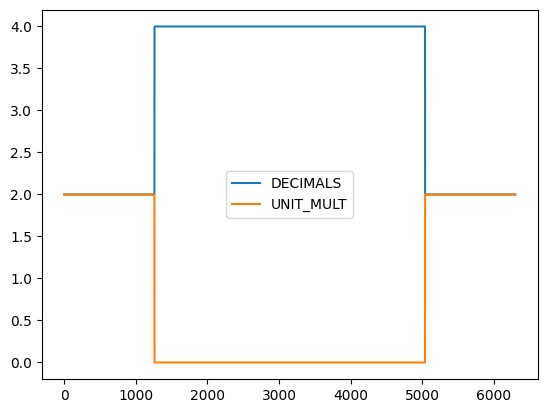

In [2]:
df.plot()


OK.  Me kan i alle fall sjå at `plot()` finst som funksjon og faktisk teiknar eit plott, sjølv om dette plottet ikkje er nyttig. Me har jo ikkje sagt kva søyler me vil ha plotta.

## Ein liten digresjon om funksjonsnotasjon

Lat oss dvela litt ved notasjonen. Me har sett fleire variantar av funksjonar.
1. `print( df )` 
2. `pd.read_csv("EXR20250401.csv", sep=";")`
3. `df.plot()`
Kvifor heiter det ikkje `df.print()` eller `plot(df)`?

Grunnen er kvar funksjonen er definert.  I det fyrste dømet er `print` ein *global* funksjon.  
Han er alltid tilgjengeleg.  Argumentet `df` fortel kva data `print` skal prenta.

I det andre dømet hentar me funksjonen `read_csv` frå eit bibliotek, pandas, som me døypte `pd` då me importerte det. Då er `pd` kjelder der me finn `read_csv` og `"EXR20250401.csv", sep=";"` er filnamn og konfigurasjon som funksjonen opererer på.

I det tredje dømet er funksjonen `plot()` definert i *objektet* `df`, som fekk verdien sin frå `pd.read_csv(...)` tidlegare.  Her treng me ikkje noko argument, fordi funksjonen allereie kjem frå, og veit om, `df`, og freistar å plotta dette objektet.


## Plottet

**Refleksjonsspørsmål** Kva søyler er interessante å plotta?

Me kan freista med `TIME_PERIOD` og `OBS_VALUE` som ser ut som dato og kurs.


In [3]:
df.plot( x="TIME_PERIOD", y="OBS_VALUE" )

TypeError: no numeric data to plot

Dette var òg for naivt. *«No numeric data to plot»* er kanskje litt overraskande, men lat oss sjå nærare på dei to søylene.  Me kan be pandas om datatypane for alle søylene, slik:


In [ ]:
df.dtypes


Dette var rart.  Der er to numeriske søyler, `DECIMALS` og `UNIT_MULT`. Dei er heiltal i intervallet $-2^{63}\ldots2^{63}-1$ (`int64`), men dei varierer lite og er neppe interessante.  På den andre sida, kan me no sjå at dette var dei to søylene som fyrst vart plotta.

Dei to søylene som interesserer oss har typen `object`, noko som kan vera nær sagt kva som helst, men ikkje noko som pandas veit å plotta. Me må altso læra å omsetja desse søylene til noko numerisk. 

## Datatypar

Datattypar kan skapa mykje forvirring når me arbeider med data, og det kan vera komplisert fordi der er uendeleg mange datatypar, og kvar type vert representert ulikt internt i maskinen og overfor brukaren. Internt i maskina er alt representert som ein serie med *bits*, der kvar *bit* er 0 eller 1, av eller på, sann eller usann; kjært barn har mange namn.  Har ein åtte *bits* (ein *byte*), kan ein tolka dei saman som eit heiltal mellom 0 og 255, eller som eit tein (bokstav eller anna) frå ein eller annan tabell. Har ein fleire *bytes* kan ein tolka det som ein teiknstreng (t.d. `"Hello World"`).

I python har me sett at teiknstrengar vert skrivne i gåseaugo, medan tal vert skrivne utan.  Difor er `100` ikkje det same som `"100"` eller `"eitt hundrede"`.  For oss kan det vera det same, men for maskina er det berre `100` som er eit tal.

I CSV-fila er alt teiknstrengar.  Det er gjort slik for at me skal kunna opna og manipulera filen enklast mogleg med ulike verkty og program. Det som framstår som `object` over er teiknstrengar som pandas ikkje klarte å forstå som noko anna. Dei andre to typane er

+ `bool`, som er kort for *Boolean* eller bolsk på norsk.  Denne typen har verdiane sann eller usann (`True` eller `False`)
+ `int64` er kort for *integer* eller heiltal, med 64 bits, som er nok for å representera positive og negative tal opp til $2^{63}$ eller cirka $8\cdot10^{18}$. Dersom me prøver å lagra tal som er større enn dette, får me ein overflytfeil. Nokre system kan varsla om slike feil, men ofte kan slike feil vera vanskeleg å finna.

Me skal straks sjå to typar til

+ `float64` er desimaltal med 64 *bits*.  *Float* er kort for *floating point number*, eller flyttal på norsk. Dette vil seia at desimalkommaet «flyt», slik at ein bruker mange desimalplassar for små tal, og få for store. Flyttal er i dag einerådande som representasjon av desimaltal. *Fixed point numbers* finst i ein del eldre programmeringsspråk, men då skal me tilbake til 1970- og 60-talet.
+ `datetime64` representerer eit tidspunkt, her ogso med 64 bits.

Det er typisk å bruka 64-*bits* tal fordi prosessorane (CPU) i dag stort sett er 64-*bits* og dermed handsamar 64-*bits*-verdiar som ein eining.  Bruker ein fleire *bits* må prosessoren handsame det i fleire omgongar, og bruker ein færre «sløser» ein med prosessorkapasiteten.


## Problemet frå Noregs Bank

**Kursen** Denne søyla ser ut som desimaltal, og det kan verka rart at pandas ikkje skjøner det. Ser me litt nøyare etter ser me at datafila bruker desimal*komma* medan pandas ventar seg det engelske desimal*punktumet*. Det er altso dette me må fiksa. Me treng då to steg, fyrst må me byta ut desimalkomma i heile søyla, og deretter må me be pandas tolka ho på nytt som tal, t.d. slik:

In [7]:
df['engelsk'] = df['OBS_VALUE'].str.replace(',', '.')
df['kurs'] = pd.to_numeric(df['engelsk'])
df.dtypes

FREQ                     object
Frekvens                 object
BASE_CUR                 object
Basisvaluta              object
QUOTE_CUR                object
Kvoteringsvaluta         object
TENOR                    object
Løpetid                  object
DECIMALS                  int64
CALCULATED                 bool
UNIT_MULT                 int64
Multiplikator            object
COLLECTION               object
Innsamlingstidspunkt     object
TIME_PERIOD              object
OBS_VALUE                object
kurs                    float64
engelsk                  object
dtype: object

Merk notasjonen.  Klammene, i `df['OBS_VALUE']` let oss adressera éi søyle i datasettet. Dette kan me gjera både på venstre og høgre side av tilordninga (`=`).  På venstre side tilordnar me ei ny søyle («engelsk» og «kurs»). På høgre side bruker me ei eksisterande søyle i utrekninga til den nye.

Den fyrste lina bruker strengfunksjonen `replace` på kvar einaste verdi i søyla. Den andre lina bruker konverteringsrutinen `to_numeric` for å lesa eit tal frå teiknstrengen. I utlistinga ser me at datasettet har fått t nye søyler, der `"kurs"` er flyttal.  Lat oss sjå på heile datasettet.

In [8]:
display(df)

,FREQ,Frekvens,BASE_CUR,Basisvaluta,QUOTE_CUR,Kvoteringsvaluta,TENOR,Løpetid,DECIMALS,CALCULATED,UNIT_MULT,Multiplikator,COLLECTION,Innsamlingstidspunkt,TIME_PERIOD,OBS_VALUE,kurs,engelsk
0,B,Virkedag,DKK,Danske kroner,NOK,Norske kroner,SP,Spot,2,False,2,Hundre,C,ECB concertation tidspunkt 14:15 CET,2020-04-01,"150,97",150.97,150.97
1,B,Virkedag,DKK,Danske kroner,NOK,Norske kroner,SP,Spot,2,False,2,Hundre,C,ECB concertation tidspunkt 14:15 CET,2020-04-02,"150,47",150.47,150.47
2,B,Virkedag,DKK,Danske kroner,NOK,Norske kroner,SP,Spot,2,False,2,Hundre,C,ECB concertation tidspunkt 14:15 CET,2020-04-03,"150,8",150.80,150.8
3,B,Virkedag,DKK,Danske kroner,NOK,Norske kroner,SP,Spot,2,False,2,Hundre,C,ECB concertation tidspunkt 14:15 CET,2020-04-06,"152,52",152.52,152.52
4,B,Virkedag,DKK,Danske kroner,NOK,Norske kroner,SP,Spot,2,False,2,Hundre,C,ECB concertation tidspunkt 14:15 CET,2020-04-07,"148,57",148.57,148.57
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6295,B,Virkedag,SEK,Svenske kroner,NOK,Norske kroner,SP,Spot,2,False,2,Hundre,C,ECB concertation tidspunkt 14:15 CET,2025-03-25,"104,74",104.74,104.74
6296,B,Virkedag,SEK,Svenske kroner,NOK,Norske kroner,SP,Spot,2,False,2,Hundre,C,ECB concertation tidspunkt 14:15 CET,2025-03-26,"104,79",104.79,104.79
6297,B,Virkedag,SEK,Svenske kroner,NOK,Norske kroner,SP,Spot,2,False,2,Hundre,C,ECB concertation tidspunkt 14:15 CET,2025-03-27,"104,8",104.80,104.8
6298,B,Virkedag,SEK,Svenske kroner,NOK,Norske kroner,SP,Spot,2,False,2,Hundre,C,ECB concertation tidspunkt 14:15 CET,2025-03-28,"104,38",104.38,104.38


Dette ser jo bra ut, men so må me gjera noko med datosøyla.  Dette er meir komplisert fordi der er so frykteleg mange måtar å skriva tidspunkt på.  Me skal bruka [`to_datetime`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.to_datetime.html)-funksjonen, som fungerer litt som `to_numeric`, bortsett frå at me må fortelja han korleis datoen er formatter, slik:

In [10]:
df['dato'] = pd.to_datetime(df['TIME_PERIOD'], format='%Y-%m-%d')
df.dtypes

FREQ                            object
Frekvens                        object
BASE_CUR                        object
Basisvaluta                     object
QUOTE_CUR                       object
Kvoteringsvaluta                object
TENOR                           object
Løpetid                         object
DECIMALS                         int64
CALCULATED                        bool
UNIT_MULT                        int64
Multiplikator                   object
COLLECTION                      object
Innsamlingstidspunkt            object
TIME_PERIOD                     object
OBS_VALUE                       object
kurs                           float64
engelsk                         object
dato                    datetime64[ns]
dtype: object

In [11]:
display(df)

,FREQ,Frekvens,BASE_CUR,Basisvaluta,QUOTE_CUR,Kvoteringsvaluta,TENOR,Løpetid,DECIMALS,CALCULATED,UNIT_MULT,Multiplikator,COLLECTION,Innsamlingstidspunkt,TIME_PERIOD,OBS_VALUE,kurs,engelsk,dato
0,B,Virkedag,DKK,Danske kroner,NOK,Norske kroner,SP,Spot,2,False,2,Hundre,C,ECB concertation tidspunkt 14:15 CET,2020-04-01,"150,97",150.97,150.97,2020-04-01
1,B,Virkedag,DKK,Danske kroner,NOK,Norske kroner,SP,Spot,2,False,2,Hundre,C,ECB concertation tidspunkt 14:15 CET,2020-04-02,"150,47",150.47,150.47,2020-04-02
2,B,Virkedag,DKK,Danske kroner,NOK,Norske kroner,SP,Spot,2,False,2,Hundre,C,ECB concertation tidspunkt 14:15 CET,2020-04-03,"150,8",150.80,150.8,2020-04-03
3,B,Virkedag,DKK,Danske kroner,NOK,Norske kroner,SP,Spot,2,False,2,Hundre,C,ECB concertation tidspunkt 14:15 CET,2020-04-06,"152,52",152.52,152.52,2020-04-06
4,B,Virkedag,DKK,Danske kroner,NOK,Norske kroner,SP,Spot,2,False,2,Hundre,C,ECB concertation tidspunkt 14:15 CET,2020-04-07,"148,57",148.57,148.57,2020-04-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6295,B,Virkedag,SEK,Svenske kroner,NOK,Norske kroner,SP,Spot,2,False,2,Hundre,C,ECB concertation tidspunkt 14:15 CET,2025-03-25,"104,74",104.74,104.74,2025-03-25
6296,B,Virkedag,SEK,Svenske kroner,NOK,Norske kroner,SP,Spot,2,False,2,Hundre,C,ECB concertation tidspunkt 14:15 CET,2025-03-26,"104,79",104.79,104.79,2025-03-26
6297,B,Virkedag,SEK,Svenske kroner,NOK,Norske kroner,SP,Spot,2,False,2,Hundre,C,ECB concertation tidspunkt 14:15 CET,2025-03-27,"104,8",104.80,104.8,2025-03-27
6298,B,Virkedag,SEK,Svenske kroner,NOK,Norske kroner,SP,Spot,2,False,2,Hundre,C,ECB concertation tidspunkt 14:15 CET,2025-03-28,"104,38",104.38,104.38,2025-03-28


## Tilbake til plotting

<Axes: xlabel='dato'>

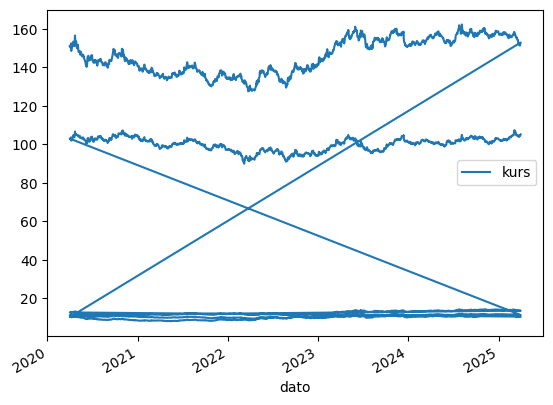

In [12]:
df.plot( "dato", "kurs")

## Skriva ut ein fil

Heilt til slutt skal me sjå korleis me kan skriva det reformatterte datasettet tilbake til fil.

In [ ]:
# Skriva ut CSV-fila
df.to_csv("EXR-formattert.csv", index=False)

Me ser ikkje noko utdata frå denne funksjonen, so for å sjå kva som skjedde, må me finna att fila i filsystemet.

**Oppgåve**
Finn fila i filsystemet og opna ho i Excel eller eit anna program. Inneheld ho det ho skal?

## Avrunding

Der er mykje å halda styr på i pandas. Her har me berre sett eitt døme og nokre få teknikkar. I neste demo skal me forklara nokre fleire grunnleggjande konsept.

* [Cheat sheet](https://pandas.pydata.org/Pandas_Cheat_Sheet.pdf)
* [Tutorials](https://pandas.pydata.org/pandas-docs/stable/getting_started/tutorials.html)
* [Kokebok](https://www.skytowner.com/explore/pandas_recipes_reference) 